In [1]:
import pandas as pd
import numpy as np
import re

import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

print("Environment setup completed successfully!")

Environment setup completed successfully!


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [8]:
import pandas as pd

df = pd.read_csv('SampleSuperstore.csv')

print("Columns in your dataset:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())


import re

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^A-Za-z0-9\s]+', '', text)
    return text



Columns in your dataset:
Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

Missing values:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [9]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

text_column = 'Category'


def get_sentiment_scores(text):
    if pd.isna(text):
        return 'Neutral'
    score = sia.polarity_scores(str(text))['compound']

    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df[text_column].apply(get_sentiment_scores)

print("Sentiment Distribution:")
print(df['Sentiment'].value_counts())

print("\nSample Data with Sentiments:")
print(df[[text_column, 'Sentiment']].head(10))

Sentiment Distribution:
Sentiment
Neutral    9994
Name: count, dtype: int64

Sample Data with Sentiments:
          Category Sentiment
0        Furniture   Neutral
1        Furniture   Neutral
2  Office Supplies   Neutral
3        Furniture   Neutral
4  Office Supplies   Neutral
5        Furniture   Neutral
6  Office Supplies   Neutral
7       Technology   Neutral
8  Office Supplies   Neutral
9  Office Supplies   Neutral


/tmp/ipykernel_3459/347219242.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Sentiment', data=df, palette='Set2', order=['Positive', 'Neutral', 'Negative'])


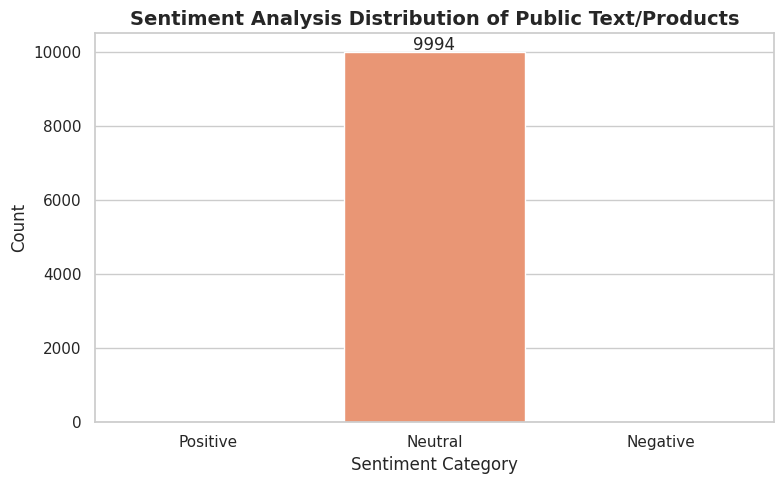

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Sentiment', data=df, palette='Set2', order=['Positive', 'Neutral', 'Negative'])


plt.title('Sentiment Analysis Distribution of Public Text/Products', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Count', fontsize=12)


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()